# Member 3 — 1D-CNN Classifier for ECG Beat Classification
**Pipeline scope:** Processed ECG → 1D-CNN → Training → Evaluation → Metrics → Graphs → Saved Model

- Input: `ecg_processed_v1.npz` (Member 2's output; **not modified** here)
- Labels: `0 = Normal`, `1 = Abnormal`
- Input shape per beat: `(360, 1)` — no extra dimension is added
- Test set is used **only** in the final evaluation (Section 13 onwards)

> Run all cells top to bottom. All numbers shown are produced by this notebook when it is executed; nothing is hard-coded.

## 01. Imports

In [ ]:
import os, random, json, time
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             classification_report, confusion_matrix, ConfusionMatrixDisplay,
                             roc_auc_score)

# Reproducibility
SEED = 42
os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED); np.random.seed(SEED); tf.random.set_seed(SEED)

# Output folders (match the repo structure)
GRAPHS_DIR, MODELS_DIR, RESULTS_DIR = "graphs", "models", "results"
for d in (GRAPHS_DIR, MODELS_DIR, RESULTS_DIR):
    os.makedirs(d, exist_ok=True)

print("TensorFlow:", tf.__version__)
print("GPUs visible:", tf.config.list_physical_devices("GPU"))

TensorFlow: 2.20.0
GPUs visible: []


## 02. Load Processed Dataset

In [ ]:
# Find ecg_processed_v1.npz: current folder, Google Drive, or upload prompt (Colab)
candidates = ["ecg_processed_v1.npz",
              "dataset/ecg_processed_v1.npz",
              "/content/ecg_processed_v1.npz",
              "/content/drive/MyDrive/ecg_processed_v1.npz",
              "/mnt/user-data/uploads/ecg_processed_v1.npz"]
DATA_PATH = next((p for p in candidates if os.path.exists(p)), None)

if DATA_PATH is None:
    try:
        from google.colab import files
        print("Dataset not found. Please upload ecg_processed_v1.npz ...")
        files.upload()
        DATA_PATH = "ecg_processed_v1.npz"
    except ImportError:
        raise FileNotFoundError("ecg_processed_v1.npz not found. Place it next to this notebook.")

data = np.load(DATA_PATH)
X_train, y_train = data["X_train"], data["y_train"]
X_val,   y_val   = data["X_val"],   data["y_val"]
X_test,  y_test  = data["X_test"],  data["y_test"]
print("Loaded:", DATA_PATH)
print("Keys  :", data.files)

Dataset not found. Please upload ecg_processed_v1.npz ...


Saving ecg_processed_v1.npz to ecg_processed_v1.npz
Loaded: ecg_processed_v1.npz
Keys  : ['X_train', 'y_train', 'X_val', 'y_val', 'X_test', 'y_test']


## 03. Verify Shapes

In [ ]:
expected = {"train": (68386, 360, 1), "val": (16399, 360, 1), "test": (15897, 360, 1)}
splits = {"train": (X_train, y_train), "val": (X_val, y_val), "test": (X_test, y_test)}

for name, (X, y) in splits.items():
    print(f"X_{name:<5}: {X.shape}  dtype={X.dtype}   y_{name:<5}: {y.shape}  dtype={y.dtype}  "
          f"labels={np.unique(y).tolist()}  NaN={int(np.isnan(X).sum())}")
    assert X.shape[1:] == (360, 1), "Input must already be (360, 1) - do not add a dimension"
    assert X.shape[0] == y.shape[0]
    assert set(np.unique(y)) <= {0, 1}
    assert not np.isnan(X).any()
    assert X.shape == expected[name], f"{name} shape differs from the shape reported by Member 2"
print("\nAll shape / label checks passed.")

X_train: (68386, 360, 1)  dtype=float32   y_train: (68386,)  dtype=int32  labels=[0, 1]  NaN=0
X_val  : (16399, 360, 1)  dtype=float32   y_val  : (16399,)  dtype=int32  labels=[0, 1]  NaN=0
X_test : (15897, 360, 1)  dtype=float32   y_test : (15897,)  dtype=int32  labels=[0, 1]  NaN=0

All shape / label checks passed.


## 04. Class Distribution

,split,total,normal(0),abnormal(1),abnormal_%
0,train,68386,62790,5596,8.18
1,val,16399,14553,1846,11.26
2,test,15897,12733,3164,19.90


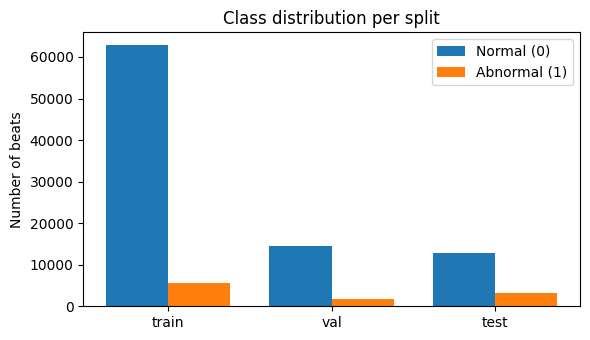

In [ ]:
rows = []
for name, (X, y) in splits.items():
    n_norm, n_abn = int((y == 0).sum()), int((y == 1).sum())
    rows.append({"split": name, "total": len(y), "normal(0)": n_norm, "abnormal(1)": n_abn,
                 "abnormal_%": round(100 * n_abn / len(y), 2)})
dist_df = pd.DataFrame(rows)
display(dist_df)

fig, ax = plt.subplots(figsize=(6, 3.5))
x = np.arange(3); w = 0.38
ax.bar(x - w/2, dist_df["normal(0)"].to_numpy(), w, label="Normal (0)")
ax.bar(x + w/2, dist_df["abnormal(1)"].to_numpy(), w, label="Abnormal (1)")
ax.set_xticks(x); ax.set_xticklabels(dist_df["split"].tolist()); ax.set_ylabel("Number of beats")
ax.set_title("Class distribution per split"); ax.legend()
plt.tight_layout(); plt.show()

**Observation:** the data is imbalanced (abnormal is the minority class), and the abnormal share differs between splits because the split is record-wise (patient-wise). This is expected and is why we use class weights and look at precision/recall/F1, not accuracy alone.

## 05. Class Weights (computed from `y_train` only)

In [ ]:
classes = np.array([0, 1])
cw = compute_class_weight(class_weight="balanced", classes=classes, y=y_train)
class_weight = {int(c): float(w) for c, w in zip(classes, cw)}
print("class_weight:", class_weight)
print("-> each abnormal beat counts about "
      f"{class_weight[1] / class_weight[0]:.1f}x more than a normal beat in the loss.")

class_weight: {0: 0.5445612358655837, 1: 6.110257326661902}
-> each abnormal beat counts about 11.2x more than a normal beat in the loss.


## 06. Build 1D-CNN

In [ ]:
def build_1d_cnn(input_shape=(360, 1)):
    """ECG Input -> Conv1D -> ReLU -> MaxPool -> Conv1D -> ReLU -> MaxPool -> Flatten -> Dense -> Output"""
    model = keras.Sequential([
        layers.Input(shape=input_shape),                                   # (360, 1)
        layers.Conv1D(32, kernel_size=5, padding="same", activation="relu"),  # (360, 32)
        layers.MaxPooling1D(pool_size=2),                                  # (180, 32)
        layers.Conv1D(64, kernel_size=5, padding="same", activation="relu"),  # (180, 64)
        layers.MaxPooling1D(pool_size=2),                                  # (90, 64)
        layers.Flatten(),                                                  # (5760,)
        layers.Dense(64, activation="relu"),                               # (64,)
        layers.Dropout(0.5),                                               # regularisation vs overfitting
        layers.Dense(1, activation="sigmoid"),                             # P(abnormal)
    ], name="cnn_1d_ecg")
    return model

model = build_1d_cnn(X_train.shape[1:])

## 07. Model Summary

In [ ]:
model.summary()

Model: "cnn_1d_ecg"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 360, 32)        │           192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 180, 32)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 180, 64)        │        10,304 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 90, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 5760)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       368,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 379,265 (1.45 MB)

 Trainable params: 379,265 (1.45 MB)

 Non-trainable params: 0 (0.00 B)

## 08. Compile

In [ ]:
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="binary_crossentropy",
    metrics=["accuracy"],
)

## 09. Train
Training uses **only** `X_train/y_train`; validation uses **only** `X_val/y_val`. Test data is not touched.

In [ ]:
MODEL_PATH = os.path.join(MODELS_DIR, "1d_cnn_model.keras")
EPOCHS, BATCH_SIZE = 30, 128

callbacks = [
    keras.callbacks.EarlyStopping(monitor="val_loss", patience=6,
                                  restore_best_weights=True, verbose=1),
    keras.callbacks.ModelCheckpoint(MODEL_PATH, monitor="val_loss",
                                    save_best_only=True, verbose=1),
    keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5,
                                      patience=2, min_lr=1e-5, verbose=1),
]

t0 = time.time()
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    class_weight=class_weight,
    callbacks=callbacks,
    verbose=2,
)
train_time = time.time() - t0
print(f"\nTraining finished in {train_time:.1f} s, epochs run: {len(history.history['loss'])}")

Epoch 1/30

Epoch 1: val_loss improved from None to 0.45434, saving model to models/1d_cnn_model.keras

Epoch 1: finished saving model to models/1d_cnn_model.keras
535/535 - 54s - 100ms/step - accuracy: 0.9438 - loss: 0.1871 - val_accuracy: 0.8145 - val_loss: 0.4543 - learning_rate: 0.0010
Epoch 2/30

Epoch 2: val_loss did not improve from 0.45434
535/535 - 53s - 99ms/step - accuracy: 0.9703 - loss: 0.1148 - val_accuracy: 0.7588 - val_loss: 0.6238 - learning_rate: 0.0010
Epoch 3/30

Epoch 3: val_loss did not improve from 0.45434

Epoch 3: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
535/535 - 81s - 151ms/step - accuracy: 0.9775 - loss: 0.0917 - val_accuracy: 0.7245 - val_loss: 0.7709 - learning_rate: 0.0010
Epoch 4/30

Epoch 4: val_loss did not improve from 0.45434
535/535 - 83s - 156ms/step - accuracy: 0.9839 - loss: 0.0703 - val_accuracy: 0.7608 - val_loss: 0.6859 - learning_rate: 5.0000e-04
Epoch 5/30

Epoch 5: val_loss did not improve from 0.45434

Epoch 5: Re

## 10. Accuracy Graph

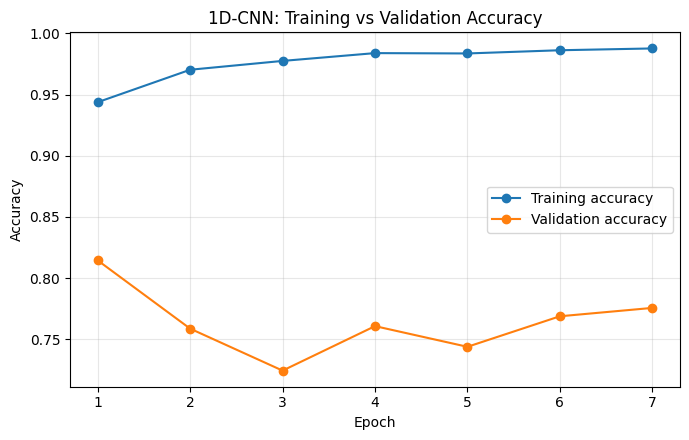

In [ ]:
h = history.history
epochs_range = range(1, len(h["accuracy"]) + 1)

plt.figure(figsize=(7, 4.5))
plt.plot(epochs_range, h["accuracy"], marker="o", label="Training accuracy")
plt.plot(epochs_range, h["val_accuracy"], marker="o", label="Validation accuracy")
plt.xlabel("Epoch"); plt.ylabel("Accuracy"); plt.title("1D-CNN: Training vs Validation Accuracy")
plt.grid(alpha=0.3); plt.legend(); plt.tight_layout()
plt.savefig(os.path.join(GRAPHS_DIR, "1d_cnn_accuracy.png"), dpi=150)
plt.show()

## 11. Loss Graph

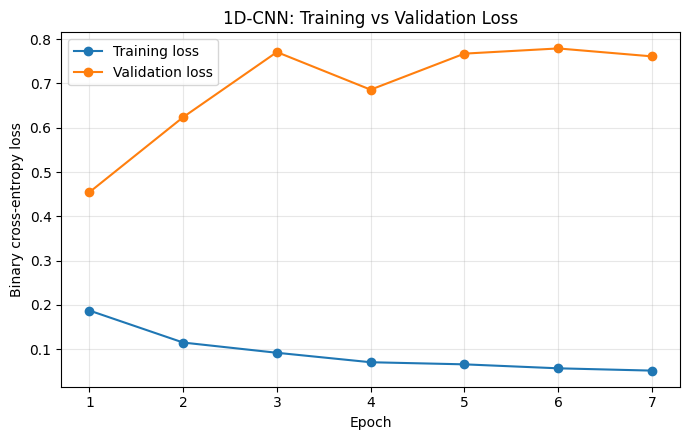

In [ ]:
plt.figure(figsize=(7, 4.5))
plt.plot(epochs_range, h["loss"], marker="o", label="Training loss")
plt.plot(epochs_range, h["val_loss"], marker="o", label="Validation loss")
plt.xlabel("Epoch"); plt.ylabel("Binary cross-entropy loss"); plt.title("1D-CNN: Training vs Validation Loss")
plt.grid(alpha=0.3); plt.legend(); plt.tight_layout()
plt.savefig(os.path.join(GRAPHS_DIR, "1d_cnn_loss.png"), dpi=150)
plt.show()

## 12. Load Best Model
Reload the checkpoint saved by `ModelCheckpoint` (lowest validation loss).

In [ ]:
best_model = keras.models.load_model(MODEL_PATH)
best_epoch = int(np.argmin(h["val_loss"])) + 1
print(f"Loaded best checkpoint from {MODEL_PATH} (best epoch by val_loss = {best_epoch}, "
      f"val_loss = {min(h['val_loss']):.4f})")

Loaded best checkpoint from models/1d_cnn_model.keras (best epoch by val_loss = 1, val_loss = 0.4543)


## 13. Test Evaluation
**First and only use of the test set.** Threshold = 0.5 on the sigmoid probability.

In [ ]:
test_loss, test_acc_keras = best_model.evaluate(X_test, y_test, batch_size=BATCH_SIZE, verbose=0)
y_prob = best_model.predict(X_test, batch_size=BATCH_SIZE, verbose=0).ravel()
y_pred = (y_prob >= 0.5).astype(int)

test_accuracy = accuracy_score(y_test, y_pred)
print(f"Test loss     : {test_loss:.4f}")
print(f"Test accuracy : {test_accuracy:.4f}  (keras evaluate: {test_acc_keras:.4f})")

Test loss     : 0.5674
Test accuracy : 0.8066  (keras evaluate: 0.8066)


## 14. Precision / Recall / F1
Positive class = **Abnormal (1)**. Macro / weighted averages are also reported.

In [ ]:
precision = precision_score(y_test, y_pred, pos_label=1, zero_division=0)
recall    = recall_score(y_test, y_pred, pos_label=1, zero_division=0)
f1        = f1_score(y_test, y_pred, pos_label=1, zero_division=0)
macro_f1  = f1_score(y_test, y_pred, average="macro", zero_division=0)
roc_auc   = roc_auc_score(y_test, y_prob)

print(f"Precision (Abnormal): {precision:.4f}")
print(f"Recall    (Abnormal): {recall:.4f}")
print(f"F1-score  (Abnormal): {f1:.4f}")
print(f"Macro F1            : {macro_f1:.4f}")
print(f"ROC-AUC             : {roc_auc:.4f}\n")

target_names = ["Normal (0)", "Abnormal (1)"]
print(classification_report(y_test, y_pred, target_names=target_names, digits=4, zero_division=0))
report_dict = classification_report(y_test, y_pred, target_names=target_names,
                                    output_dict=True, zero_division=0)

Precision (Abnormal): 0.5139
Recall    (Abnormal): 0.5193
F1-score  (Abnormal): 0.5166
Macro F1            : 0.6978
ROC-AUC             : 0.8448

              precision    recall  f1-score   support

  Normal (0)     0.8802    0.8780    0.8791     12733
Abnormal (1)     0.5139    0.5193    0.5166      3164

    accuracy                         0.8066     15897
   macro avg     0.6971    0.6986    0.6978     15897
weighted avg     0.8073    0.8066    0.8069     15897



## 15. Confusion Matrix

TN=11179  FP=1554  FN=1521  TP=1643


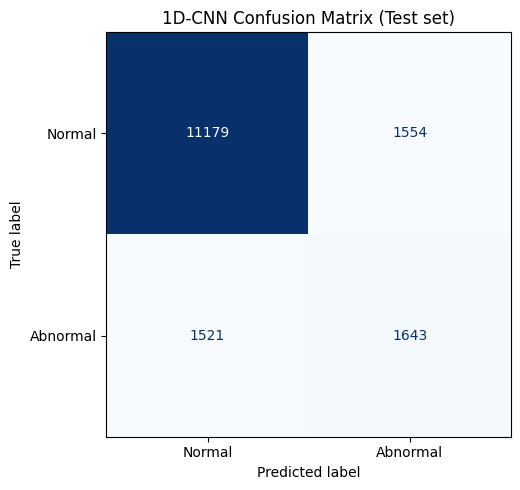

In [ ]:
cm = confusion_matrix(y_test, y_pred, labels=[0, 1])
tn, fp, fn, tp = cm.ravel()
print(f"TN={tn}  FP={fp}  FN={fn}  TP={tp}")

fig, ax = plt.subplots(figsize=(5.5, 5))
ConfusionMatrixDisplay(cm, display_labels=["Normal", "Abnormal"]).plot(ax=ax, cmap="Blues", colorbar=False, values_format="d")
ax.set_title("1D-CNN Confusion Matrix (Test set)")
plt.tight_layout()
plt.savefig(os.path.join(GRAPHS_DIR, "1d_cnn_confusion_matrix.png"), dpi=150)
plt.show()

## 16. Save Model
The best model was already written by `ModelCheckpoint`; we re-save the loaded best model to be explicit.

In [ ]:
best_model.save(MODEL_PATH)
print("Saved:", MODEL_PATH, f"({os.path.getsize(MODEL_PATH)/1024:.1f} KB)")

Saved: models/1d_cnn_model.keras (4482.9 KB)


## 17. Save Metrics

In [ ]:
metrics_df = pd.DataFrame([{
    "model": "1D-CNN",
    "test_accuracy": test_accuracy,
    "test_loss": test_loss,
    "precision_abnormal": precision,
    "recall_abnormal": recall,
    "f1_abnormal": f1,
    "macro_f1": macro_f1,
    "roc_auc": roc_auc,
    "TN": int(tn), "FP": int(fp), "FN": int(fn), "TP": int(tp),
    "best_epoch": best_epoch,
    "epochs_run": len(h["loss"]),
    "batch_size": BATCH_SIZE,
    "training_time_sec": round(train_time, 1),
    "n_params": int(best_model.count_params()),
}])
metrics_df.to_csv(os.path.join(RESULTS_DIR, "1d_cnn_metrics.csv"), index=False)

report_df = pd.DataFrame(report_dict).T
report_df.index.name = "class"
report_df.to_csv(os.path.join(RESULTS_DIR, "1d_cnn_classification_report.csv"))

print("Saved results/1d_cnn_metrics.csv and results/1d_cnn_classification_report.csv")

Saved results/1d_cnn_metrics.csv and results/1d_cnn_classification_report.csv


## 18. Final Results

In [ ]:
print("=" * 55)
print(" MEMBER 3 - 1D-CNN FINAL RESULTS (test set, best checkpoint)")
print("=" * 55)
print(f" Test accuracy       : {test_accuracy:.4f}")
print(f" Precision (Abnormal): {precision:.4f}")
print(f" Recall    (Abnormal): {recall:.4f}")
print(f" F1-score  (Abnormal): {f1:.4f}")
print(f" ROC-AUC             : {roc_auc:.4f}")
print(f" Confusion matrix    : TN={tn} FP={fp} FN={fn} TP={tp}")
print(f" Best epoch          : {best_epoch} / {len(h['loss'])} run")
print("=" * 55)
display(metrics_df.T.rename(columns={0: "value"}))
display(report_df)

print("\nGenerated files:")
for p in [os.path.join(GRAPHS_DIR, f) for f in ("1d_cnn_accuracy.png", "1d_cnn_loss.png", "1d_cnn_confusion_matrix.png")] + \
         [MODEL_PATH, os.path.join(RESULTS_DIR, "1d_cnn_metrics.csv"),
          os.path.join(RESULTS_DIR, "1d_cnn_classification_report.csv")]:
    print(("  OK  " if os.path.exists(p) else "  MISSING  ") + p)

 MEMBER 3 - 1D-CNN FINAL RESULTS (test set, best checkpoint)
 Test accuracy       : 0.8066
 Precision (Abnormal): 0.5139
 Recall    (Abnormal): 0.5193
 F1-score  (Abnormal): 0.5166
 ROC-AUC             : 0.8448
 Confusion matrix    : TN=11179 FP=1554 FN=1521 TP=1643
 Best epoch          : 1 / 7 run


,value
model,1D-CNN
test_accuracy,0.806567
test_loss,0.567428
precision_abnormal,0.513919
recall_abnormal,0.519279
f1_abnormal,0.516585
macro_f1,0.69784
roc_auc,0.844828
TN,11179
FP,1554


,precision,recall,f1-score,support
class,,,,
Normal (0),0.880236,0.877955,0.879094,12733.000000
Abnormal (1),0.513919,0.519279,0.516585,3164.000000
accuracy,0.806567,0.806567,0.806567,0.806567
macro avg,0.697078,0.698617,0.697840,15897.000000
weighted avg,0.807328,0.806567,0.806944,15897.000000



Generated files:
  OK  graphs/1d_cnn_accuracy.png
  OK  graphs/1d_cnn_loss.png
  OK  graphs/1d_cnn_confusion_matrix.png
  OK  models/1d_cnn_model.keras
  OK  results/1d_cnn_metrics.csv
  OK  results/1d_cnn_classification_report.csv


In [ ]:
!zip -r Member3_1D_CNN_Final.zip graphs models results 03_1d_cnn_member3.ipynb


	zip warning: name not matched: 03_1d_cnn_member3.ipynb
  adding: graphs/ (stored 0%)
  adding: graphs/1d_cnn_loss.png (deflated 11%)
  adding: graphs/1d_cnn_confusion_matrix.png (deflated 20%)
  adding: graphs/1d_cnn_accuracy.png (deflated 11%)
  adding: models/ (stored 0%)
  adding: models/1d_cnn_model.keras (deflated 9%)
  adding: results/ (stored 0%)
  adding: results/1d_cnn_metrics.csv (deflated 32%)
  adding: results/1d_cnn_classification_report.csv (deflated 46%)


In [ ]:
!ls

ecg_processed_v1.npz  Member3_1D_CNN_Final.zip	results
graphs		      models			sample_data


In [ ]:
from google.colab import files
files.download("Member3_1D_CNN_Final.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>